In [17]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

from transformers import ViTForImageClassification


In [18]:
path = "dataset"
model_folder = "model"
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

IMG_SIZE = 224

X_file = os.path.join(model_folder, "DL_X.npy")
Y_file = os.path.join(model_folder, "DL_Y.npy")

if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print("Saved arrays loaded.")
else:
    X, Y = [], []
    for category in categories:
        folder = os.path.join(path, category)
        label = categories.index(category)

        for img_name in os.listdir(folder):
            if 'Thumbs.db' in img_name:
                continue

            img = cv2.imread(os.path.join(folder, img_name))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0  # normalization

            X.append(img)
            Y.append(label)

    X = np.array(X)
    Y = np.array(Y)

    np.save(X_file, X)
    np.save(Y_file, Y)

Y_cat = to_categorical(Y, num_classes=len(categories))


Saved arrays loaded.


In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, Y_cat, test_size=0.35, random_state=77)


In [20]:
def calculateMetrics(name, pred_classes, true_classes):
    p = precision_score(true_classes, pred_classes, average='macro')*100
    r = recall_score(true_classes, pred_classes, average='macro')*100
    f = f1_score(true_classes, pred_classes, average='macro')*100
    a = accuracy_score(true_classes, pred_classes)*100

    print(f"\n{name} Accuracy  : {a}")
    print(f"{name} Precision : {p}")
    print(f"{name} Recall    : {r}")
    print(f"{name} F1 Score  : {f}")

    print("\nClassification Report\n", classification_report(true_classes, pred_classes, target_names=categories))

    cm = confusion_matrix(true_classes, pred_classes)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=categories, yticklabels=categories)
    plt.title(name+" Confusion Matrix")
    plt.show()


CNN model loaded.
8/8 [==============================] - 8s 838ms/step

Custom CNN Accuracy  : 82.0408163265306
Custom CNN Precision : 82.6933495868888
Custom CNN Recall    : 82.18333333333334
Custom CNN F1 Score  : 81.99010959636462

Classification Report
               precision    recall  f1-score   support

        fake       0.78      0.89      0.83       120
        real       0.88      0.75      0.81       125

    accuracy                           0.82       245
   macro avg       0.83      0.82      0.82       245
weighted avg       0.83      0.82      0.82       245



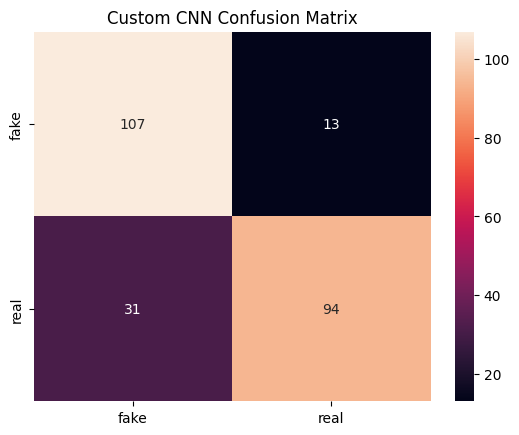

In [21]:
cnn_path = os.path.join(model_folder, "CNN_Model.h5")

if os.path.exists(cnn_path):
    cnn_model = load_model(cnn_path)
    print("CNN model loaded.")
else:
    cnn_model = Sequential([
        Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128,(3,3),activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(256,activation='relu'),
        Dropout(0.5),
        Dense(len(categories),activation='softmax')
    ])

    cnn_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    cnn_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
    cnn_model.save(cnn_path)
    print("CNN model trained and saved.")

pred = cnn_model.predict(x_test)
calculateMetrics("Custom CNN", np.argmax(pred,axis=1), np.argmax(y_test,axis=1))


ResNet50 model loaded.
8/8 [==============================] - 28s 3s/step

ResNet50 Accuracy  : 55.10204081632652
ResNet50 Precision : 56.855237154150196
ResNet50 Recall    : 55.55
ResNet50 F1 Score  : 53.06840345500139

Classification Report
               precision    recall  f1-score   support

        fake       0.53      0.78      0.63       120
        real       0.61      0.34      0.43       125

    accuracy                           0.55       245
   macro avg       0.57      0.56      0.53       245
weighted avg       0.57      0.55      0.53       245



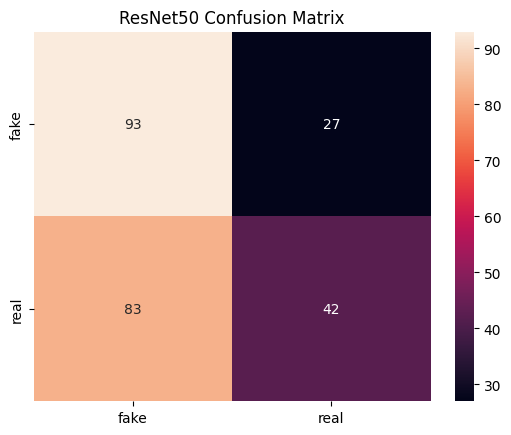

In [22]:
resnet_path = os.path.join(model_folder, "ResNet50_Model.h5")

if os.path.exists(resnet_path):
    resnet_model = load_model(resnet_path)
    print("ResNet50 model loaded.")
else:
    base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    for layer in base_resnet.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_resnet.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(len(categories), activation='softmax')(x)

    resnet_model = Model(inputs=base_resnet.input, outputs=output)
    resnet_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    resnet_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
    resnet_model.save(resnet_path)
    print("ResNet50 model trained and saved.")

pred = resnet_model.predict(x_test)
calculateMetrics("ResNet50", np.argmax(pred,axis=1), np.argmax(y_test,axis=1))


VGG16 model loaded.
8/8 [==============================] - 65s 8s/step

VGG16 Accuracy  : 76.32653061224491
VGG16 Precision : 76.65725426919457
VGG16 Recall    : 76.43333333333334
VGG16 F1 Score  : 76.294541572134

Classification Report
               precision    recall  f1-score   support

        fake       0.73      0.82      0.77       120
        real       0.80      0.71      0.75       125

    accuracy                           0.76       245
   macro avg       0.77      0.76      0.76       245
weighted avg       0.77      0.76      0.76       245



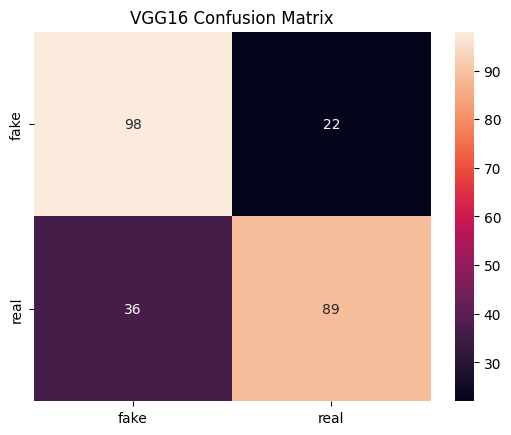

In [23]:
vgg_path = os.path.join(model_folder, "VGG16_Model.h5")

if os.path.exists(vgg_path):
    vgg_model = load_model(vgg_path)
    print("VGG16 model loaded.")
else:
    base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
    for layer in base_vgg.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_vgg.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(len(categories), activation='softmax')(x)

    vgg_model = Model(inputs=base_vgg.input, outputs=output)
    vgg_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    vgg_model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))
    vgg_model.save(vgg_path)
    print("VGG16 model trained and saved.")

pred = vgg_model.predict(x_test)
calculateMetrics("VGG16", np.argmax(pred,axis=1), np.argmax(y_test,axis=1))


EfficientNet model loaded.
8/8 [==============================] - 47s 5s/step

EfficientNet Fake Detection Accuracy  : 53.46938775510204
EfficientNet Fake Detection Precision : 53.50140056022409
EfficientNet Fake Detection Recall    : 53.5
EfficientNet Fake Detection F1 Score  : 53.46861255497801

Classification Report
               precision    recall  f1-score   support

        fake       0.52      0.55      0.54       120
        real       0.55      0.52      0.53       125

    accuracy                           0.53       245
   macro avg       0.54      0.54      0.53       245
weighted avg       0.54      0.53      0.53       245



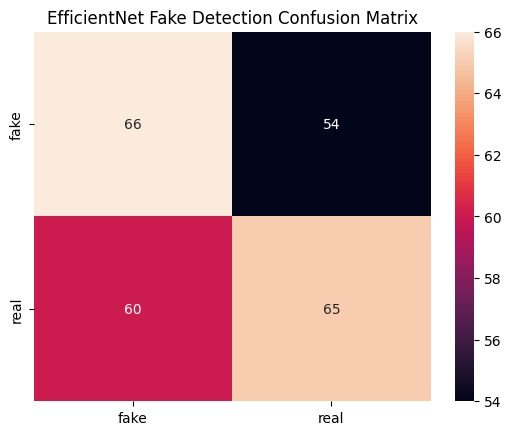

In [24]:
eff_path = os.path.join(model_folder, "EfficientNet_FakeDetect.h5")

if os.path.exists(eff_path):
    eff_model = load_model(eff_path)
    print("EfficientNet model loaded.")
else:
    base = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224,224,3))
    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    out = Dense(2, activation='softmax')(x)

    eff_model = Model(base.input, out)
    eff_model.compile(optimizer=Adam(0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
    eff_model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
    eff_model.save(eff_path)
    print("EfficientNet trained & saved.")

pred = np.argmax(eff_model.predict(x_test), axis=1)
calculateMetrics("EfficientNet Fake Detection", pred, np.argmax(y_test,axis=1))


1/1 [==============================] - 0s 129ms/step


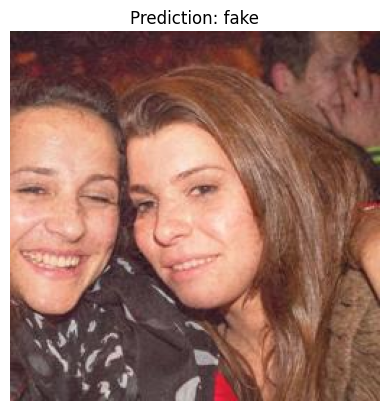

In [27]:
def predict_image(path, model):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    label = categories[np.argmax(pred)]

    plt.imshow(cv2.imread(path)[:,:,::-1])
    plt.title("Prediction: "+label)
    plt.axis('off')
    plt.show()

    cnn_model = Sequential
    cnn_model = Sequential
    cnn_model = load_model(cnn_path)
predict_image(r"C:\Users\Palla\OneDrive\Desktop\deep fake vikas\deep fake vikas\dataset\fake\fake_52.jpg", cnn_model)
